# MK Open Data → SUSI Allometry Inputs

Extract representative peatland forest stand structures from the Metsäkeskus
GeoPackage, build the three-species allometric road-map tables required by
SUSI, and write them to `.xlsx` files **and** to an XML file that can be
re-used with `xml_to_allometry.py`.

## Workflow
```
GeoPackage  →  filter (maingroup=1, subgroup∈{2,3}, drainagestate∈{7-9},
                        developmentclass∈{1,2,3})
            →  latest measured treestand (type=1)
            →  treestandsummary + treestratum
            →  aggregate strata to [pine | spruce | deciduous]
            →  stratified sample: N stands per (fertilityclass × devclass × subgroup)
            →  Growth_and_Yield_Table → .xlsx (SUSI allometry)
            →  XML documentation file (can be replayed through xml_to_allometry.py)
```

**Stand strata mapping to SUSI**

| Allometry slot | species codes in MK data |
|---|---|
| Stratum 1 – Pine   | treespecies = 1 |
| Stratum 2 – Spruce | treespecies = 2 |
| Stratum 3 – Deciduous | treespecies ∈ {3,4,5,6,7,8,9} |

Missing species slots are filled with dummy values (BA = 0, N = 0).


In [8]:
"""

"""
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
TARGET_YEAR = 2018
# ── Paths ────────────────────────────────────────────────────────────────────
BASE_DIR     = Path(".").resolve()
INPUT_GPKG   = BASE_DIR / "DATA" / "MV_Uusimaa.gpkg"
XML_OUT_DIR  = BASE_DIR / "DATA" / "susi_xml_inputs" / str(TARGET_YEAR)
XLSX_OUT_DIR = BASE_DIR / "DATA" / "susi_allometry" / str(TARGET_YEAR)

XML_OUT_DIR.mkdir(parents=True, exist_ok=True)
XLSX_OUT_DIR.mkdir(parents=True, exist_ok=True)

# Path to the susi_26 source tree (for Growth_and_Yield_Table and helpers)
SUSI_SRC = Path("/Users/sandeep/susi_26/src")
if str(SUSI_SRC) not in sys.path:
    sys.path.insert(0, str(SUSI_SRC))

# ── Stand filters ─────────────────────────────────────────────────────────────
MAINGROUP_FILTER        = [1]         # 1 = Forest land
SUBGROUP_FILTER         = [2, 3]      # 2 = Korpi (spruce mire), 3 = Räme (pine mire)
DEVELOPMENTCLASS_FILTER = [1, 2, 3]   # 1 = open/seedling, 2 = young growing, 3 = grown-up
DRAINAGESTATE_FILTER    = [7, 8, 9]   # drained peatland development stages
FERTILITYCLASS_FILTER   = [2, 3, 4, 5]  # peatland fertility classes of interest

# ── Representative sampling ────────────────────────────────────────────────────
# Development class 1 (open/seedling stands) is structurally simpler and
# less variable — 5 representatives are sufficient.
# Development classes 2 and 3 span a wider BA/age range — 15 each.
#
# OLD single value:  N_PER_STRATUM = 5
# NEW per-DC dict:   N_PER_DC = {dc: n_stands}
N_PER_DC: dict[int, int] = {
    1: 5,    # open / seed-tree stage
    2: 15,   # young growing forest
    3: 15,   # grown-up growing forest
}

# ── Region metadata 
REGION_TAG = "Uusimaa" 

REGION_META_MAP: dict[str, dict] = {
    "Uusimaa":            dict(DDY=1250, y=6700, x=24, altitude=50),
    "Kanta-Hame":         dict(DDY=1200, y=6785, x=26, altitude=100),
    "Pirkanmaa":          dict(DDY=1150, y=6835, x=24, altitude=130),
    "Pohjanmaa":          dict(DDY=1050, y=7020, x=22, altitude=30),
    "Pohjois-Pohjanmaa":  dict(DDY=950,  y=7180, x=27, altitude=40),
    "Kainuu":             dict(DDY=900,  y=7200, x=29, altitude=200),
    "Lappi":              dict(DDY=800,  y=7400, x=26, altitude=120),
}
REGION_META = REGION_META_MAP.get(
    REGION_TAG,
    dict(DDY=1100, y=6900, x=27, altitude=100),
)

SUBGROUP_LABEL = {2: "Korpi", 3: "Rame"}

print(f"Input  : {INPUT_GPKG}")
print(f"XLSX out: {XLSX_OUT_DIR}")
print(f"Region : {REGION_TAG} — DDY={REGION_META['DDY']}")
print(f"N per DC: {N_PER_DC}")


Input  : /home/txart/projects/hiket/susi_26/DATA/MV_Uusimaa.gpkg
XLSX out: /home/txart/projects/hiket/susi_26/DATA/susi_allometry/2018
Region : Uusimaa — DDY=1250
N per DC: {1: 5, 2: 15, 3: 15}


In [9]:
"""
Load GeoPackage layers and filter to drained peatland forest stands.
NOTE: MK Uusimaa data downloaded from: https://avoin.metsakeskus.fi/aineistot/Metsavarakuviot/Maakunta/MV_Uusimaa.zip
"""
import geopandas as gpd
import pandas as pd
import numpy as np

# ── Load layers ───────────────────────────────────────────────────────────────
stand         = gpd.read_file(INPUT_GPKG, layer="stand")
treestand     = gpd.read_file(INPUT_GPKG, layer="treestand")
treestandsumm = gpd.read_file(INPUT_GPKG, layer="treestandsummary")
treestratum   = gpd.read_file(INPUT_GPKG, layer="treestratum")

print(f"stand          : {len(stand):>7,} rows")
print(f"treestand      : {len(treestand):>7,} rows")
print(f"treestandsumm  : {len(treestandsumm):>7,} rows")
print(f"treestratum    : {len(treestratum):>7,} rows")

# ── Coerce filter columns to numeric ─────────────────────────────────────────
for col in ["maingroup", "subgroup", "drainagestate", "fertilityclass"]:
    stand[col] = pd.to_numeric(stand[col], errors="coerce")

# ── Filter stands ─────────────────────────────────────────────────────────────
mask = (
    stand["maingroup"].isin(MAINGROUP_FILTER) &
    stand["subgroup"].isin(SUBGROUP_FILTER) &
    stand["drainagestate"].isin(DRAINAGESTATE_FILTER) &
    stand["fertilityclass"].isin(FERTILITYCLASS_FILTER)
)
peat_stands = stand[mask].copy()
print(f"\nFiltered peatland forest stands: {len(peat_stands):,}")
print(peat_stands[["standid", "subgroup", "fertilityclass", "drainagestate", "area"]].head(5).to_string(index=False))


stand          : 429,164 rows
treestand      : 1,235,876 rows
treestandsumm  : 852,631 rows
treestratum    : 2,297,066 rows

Filtered peatland forest stands: 13,488
 standid  subgroup  fertilityclass  drainagestate  area
74396651         3               5            8.0 0.100
74401631         2               3            8.0 0.030
74401635         2               3            8.0 0.083
74401628         2               3            8.0 0.037
10809465         2               2            9.0 1.813


In [10]:
"""
 Select treestand per stand for a TARGET year (2005 or the earliest available year >= 2005),
 then attach stand-level site attributes.

Date selection logic:
  - Keep only type=1 (measured/inventoried) records.
  - TARGET_YEAR = 2005 (configurable below).
  - For each stand, prefer the record whose year == TARGET_YEAR.
    If no record exists in that year, fall back to the earliest year > TARGET_YEAR.
    Stands with no type=1 record >= TARGET_YEAR are excluded with a warning.
  - A summary table shows how many stands were matched per year so you can
    see which actual inventory dates were used.

This version intentionally does NOT join treestandsummary, because keys do not overlap
in this dataset (treestand <-> treestandsummary join path unresolved).
"""

import numpy as np
import pandas as pd

# ── Target year (edit this to change which inventory snapshot is used) ────────
  # use this year's measurement; if absent, use earliest year > TARGET_YEAR

# 1) Restrict treestand rows to peat stands selected in Cell 3
ts = treestand[treestand["standid"].isin(peat_stands["standid"])].copy()

# 2) Parse date/type and keep measured records (type=1) when available
ts["date_dt"] = pd.to_datetime(ts["date"], errors="coerce")
ts["type_num"] = pd.to_numeric(ts["type"], errors="coerce")
ts["year"]    = ts["date_dt"].dt.year

ts_measured = ts[ts["type_num"] == 1].copy()
if len(ts_measured) == 0:
    print("Warning: no type=1 measured treestands found, using all types.")
    ts_measured = ts.copy()

# 3) Show all available inventory years so you know what is in the data
print("Available measured inventory years (type=1):")
year_counts = (
    ts_measured.groupby("year")["standid"]
    .nunique()
    .reset_index()
    .rename(columns={"standid": "n_stands"})
    .sort_values("year")
)
print(year_counts.to_string(index=False))
print()

# 4) Select TARGET_YEAR or earliest year after it, per stand
#    Step A: keep only records with year >= TARGET_YEAR
ts_exact = ts_measured[ts_measured["year"] == TARGET_YEAR].copy()
#ts_gte = ts_measured[ts_measured["year"] >= TARGET_YEAR].copy()

#    Step B: for each stand, pick the record closest to TARGET_YEAR
#            (i.e. prefer TARGET_YEAR itself; otherwise take the next available year)
latest_ts = (
    ts_exact
    .sort_values(["standid", "date_dt"])   # ascending year → closest to TARGET_YEAR first #removed "year"
    .drop_duplicates(subset="standid", keep="first")
    .reset_index(drop=True)
)

n_excluded = peat_stands["standid"].nunique() - latest_ts["standid"].nunique()
if n_excluded > 0:
    print(f"Warning: {n_excluded} stand(s) had no type=1 record in {TARGET_YEAR} — excluded.")

# 5) Report which actual years were selected
print(f"Treestand records selected (TARGET_YEAR={TARGET_YEAR}):")
selected_year_counts = (
    latest_ts.groupby("year")["standid"]
    .count()
    .reset_index()
    .rename(columns={"standid": "n_stands"})
)
print(selected_year_counts.to_string(index=False))
print(f"  → Total stands selected: {len(latest_ts):,}")
print()

# 6) Bring stand-layer attributes (robust join key: standid)
stand_cols_preferred = [
    "standid",
    "subgroup",
    "fertilityclass",
    "drainagestate",
    "soiltype",
    "area",
    "geometry",
    "developmentclass",
]
stand_cols = [c for c in stand_cols_preferred if c in peat_stands.columns]

stand_attr = peat_stands[stand_cols].copy()

merged = latest_ts.merge(stand_attr, on="standid", how="left")

# 7) Keep placeholders for summary columns so downstream code never KeyErrors
summary_placeholder_cols = [
    "meanage",
    "basalarea",
    "stemcount",
    "meandiameter",
    "meanheight",
    "dominantheight",
    "volume",
    "maintreespecies",
]
for c in summary_placeholder_cols:
    if c not in merged.columns:
        merged[c] = np.nan

# 8) Development class filter
merged["developmentclass"] = pd.to_numeric(merged["developmentclass"], errors="coerce")
merged_filtered = merged[merged["developmentclass"].isin([1, 2, 3])].copy()

print(f"After developmentclass filter (DC in [1,2,3]): {len(merged_filtered):,} stands")
print()
print("Columns after Cell 4:", list(merged_filtered.columns))
print()
print(
    merged_filtered[
        ["standid", "subgroup", "fertilityclass", "developmentclass", "treestandid"]
    ]
    .head(8)
    .to_string(index=False)
)


Available measured inventory years (type=1):
 year  n_stands
 1990         4
 1991        13
 1992         2
 1993         2
 1994         2
 1997        12
 1998         3
 1999         2
 2000         2
 2001         7
 2002        22
 2003        13
 2004        13
 2005        11
 2006        46
 2007        45
 2008        67
 2009        66
 2010       491
 2011       749
 2012        65
 2013        51
 2014        33
 2015        14
 2016        39
 2017        29
 2018       917
 2019        14
 2020      1482
 2021      1343
 2022       730
 2023      2995
 2024      1706
 2025      1132

Treestand records selected (TARGET_YEAR=2018):
 year  n_stands
 2018       917
  → Total stands selected: 917

After developmentclass filter (DC in [1,2,3]): 804 stands

Columns after Cell 4: ['treestandid', 'standid', 'date', 'type', 'datasource', 'creationtime', 'updatetime', 'date_dt', 'type_num', 'year', 'subgroup', 'fertilityclass', 'drainagestate', 'soiltype', 'area', 'geometry', 'deve

In [11]:
"""
 Load treestratum for selected stands and aggregate each stand's
 strata to exactly three slots: [pine | spruce | deciduous].
"""
import math
import numpy as np
import pandas as pd

PINE_SP   = {1}
SPRUCE_SP = {2}
DECID_SP  = {3, 4, 5, 6, 7, 8, 9, 15, 20, 29}

selected_ids = set(pd.to_numeric(merged_filtered["treestandid"], errors="coerce").dropna().astype("Int64"))

strata_raw = treestratum[
    pd.to_numeric(treestratum["treestandid"], errors="coerce").astype("Int64").isin(selected_ids)
].copy()

for c in ["treestandid", "treespecies", "age", "basalarea", "stemcount", "meandiameter", "meanheight", "stratumnumber"]:
    if c in strata_raw.columns:
        strata_raw[c] = pd.to_numeric(strata_raw[c], errors="coerce")

print(f"Treestratum rows for selected stands: {len(strata_raw):,}")
if len(strata_raw) > 0:
    print("treespecies value counts:", strata_raw["treespecies"].value_counts(dropna=False).to_dict())


def _estimate_stemcount(total_ba: float, dg_cm: float) -> int:
    if total_ba > 0 and pd.notna(dg_cm) and dg_cm > 0:
        ba_per_tree = math.pi * (dg_cm / 2 / 100) ** 2
        return max(1, int(round(total_ba / ba_per_tree)))
    return 0


def _aggregate_species_group(rows: pd.DataFrame) -> dict | None:
    if rows.empty:
        return None

    total_ba = float(rows["basalarea"].sum(skipna=True))
    total_n = float(rows["stemcount"].sum(skipna=True))

    if total_ba > 0:
        wt = rows["basalarea"].fillna(0.0)
        age_w = (rows["age"].fillna(0.0) * wt).sum() / total_ba
        dg_w = (rows["meandiameter"].fillna(0.0) * wt).sum() / total_ba
        hg_w = (rows["meanheight"].fillna(0.0) * wt).sum() / total_ba
    else:
        age_w = rows["age"].mean()
        dg_w = rows["meandiameter"].mean()
        hg_w = rows["meanheight"].mean()

    dg_final = float(dg_w) if (pd.notna(dg_w) and dg_w > 0) else 5.0
    hg_final = float(hg_w) if (pd.notna(hg_w) and hg_w > 0) else 3.0

    if (pd.isna(total_n) or total_n <= 0) and total_ba > 0:
        total_n = _estimate_stemcount(total_ba, dg_final)

    return {
        "age": max(1, int(round(age_w))) if pd.notna(age_w) else 30,
        "basalarea": total_ba,
        "stemcount": int(round(total_n)) if pd.notna(total_n) and total_n > 0 else 0,
        "meandiameter": dg_final,
        "meanheight": hg_final,
    }


def build_three_strata(stand_strata: pd.DataFrame, dominant_age: int):
    dummy = {
        "age": dominant_age,
        "basalarea": 0.0,
        "stemcount": 0,
        "meandiameter": 5.0,
        "meanheight": 3.0,
    }
    pine = _aggregate_species_group(stand_strata[stand_strata["treespecies"].isin(PINE_SP)]) or dummy.copy()
    spr = _aggregate_species_group(stand_strata[stand_strata["treespecies"].isin(SPRUCE_SP)]) or dummy.copy()
    decid = _aggregate_species_group(stand_strata[stand_strata["treespecies"].isin(DECID_SP)]) or dummy.copy()
    return pine, spr, decid


records = []
skipped_zero_ba = 0

for _, row in merged_filtered.iterrows():
    tsid = pd.to_numeric(pd.Series([row.get("treestandid")]), errors="coerce").iloc[0]
    if pd.isna(tsid):
        continue

    tsid = int(tsid)
    stand_strata = strata_raw[strata_raw["treestandid"].astype("Int64") == tsid]

    dom_age = int(row["meanage"]) if pd.notna(row.get("meanage")) else 30
    pine, spr, decid = build_three_strata(stand_strata, dom_age)

    total_ba = float(pine["basalarea"] + spr["basalarea"] + decid["basalarea"])
    if total_ba <= 0:
        skipped_zero_ba += 1
        continue

    stand_age = (
        pine["age"] * pine["basalarea"]
        + spr["age"] * spr["basalarea"]
        + decid["age"] * decid["basalarea"]
    ) / total_ba

    stand_hg = (
        pine["meanheight"] * pine["basalarea"]
        + spr["meanheight"] * spr["basalarea"]
        + decid["meanheight"] * decid["basalarea"]
    ) / total_ba

    stand_dg = (
        pine["meandiameter"] * pine["basalarea"]
        + spr["meandiameter"] * spr["basalarea"]
        + decid["meandiameter"] * decid["basalarea"]
    ) / total_ba

    ba_slots = {"pine": pine["basalarea"], "spruce": spr["basalarea"], "deciduous": decid["basalarea"]}
    main_sp_str = max(ba_slots, key=ba_slots.get)
    main_sp_code = {"pine": 1, "spruce": 2, "deciduous": 3}[main_sp_str]

    records.append(
        {
            "standid": row["standid"],
            "treestandid": tsid,
            "subgroup": int(row["subgroup"]) if pd.notna(row.get("subgroup")) else None,
            "fertilityclass": int(row["fertilityclass"]) if pd.notna(row.get("fertilityclass")) else None,
            "developmentclass": int(row["developmentclass"]) if pd.notna(row.get("developmentclass")) else None,
            "drainagestate": row.get("drainagestate"),
            "soiltype": row.get("soiltype"),
            "date": row.get("date"),
            "stand_meanage": float(stand_age),          # fixed
            "stand_basalarea": float(total_ba),         # fixed
            "stand_meanheight": float(stand_hg),
            "stand_meandiameter": float(stand_dg),
            "stand_volume": row.get("volume"),
            "geometry": row.get("geometry"),
            "main_species": main_sp_code,
            "pine": pine,
            "spruce": spr,
            "decid": decid,
        }
    )

stands_df = pd.DataFrame(records)
print(f"\nValid stands with 3-stratum data: {len(stands_df):,}")
print(f"Skipped stands with zero BA: {skipped_zero_ba:,}")

if len(stands_df) == 0:
    print("\nNo valid stands produced.")
else:
    display_cols = [
        c for c in [
            "standid", "subgroup", "fertilityclass", "developmentclass",
            "stand_basalarea", "stand_meanage", "main_species"
        ] if c in stands_df.columns
    ]
    print(stands_df[display_cols].head(8).to_string(index=False))

Treestratum rows for selected stands: 2,207
treespecies value counts: {2: 754, 1: 753, 29: 696, 3: 2, 4: 1, 9: 1}

Valid stands with 3-stratum data: 786
Skipped stands with zero BA: 18
 standid  subgroup  fertilityclass  developmentclass  stand_basalarea  stand_meanage  main_species
 3672691         3               4                 3            22.03      45.130731             3
13051239         2               2                 3            30.79      62.899643             3
13552490         3               4                 3            20.38      55.524534             1
13569023         2               3                 3            19.19      56.663366             2
29589122         2               3                 3            21.42      44.599440             2
29589850         2               3                 2             9.85      26.686294             2
31560939         2               3                 3            15.00      30.000000             2
31729404         2     

In [12]:
"""
Select representative stands per stratum using evenly-spaced BA
quantiles, with per-development-class sample sizes (N_PER_DC).

Development class 1 (open/seedling): N=5
Development classes 2 & 3 (young/grown-up): N=15 each

OLD: N_PER_STRATUM = 5  (single value used for all DC)
NEW: N_PER_DC = {1: 5, 2: 15, 3: 15}  — sample size varies by DC
"""

def select_quantile_representatives(group: pd.DataFrame, n: int) -> pd.DataFrame:
    """Return up to n rows from group at evenly-spaced BA quantiles."""
    group = group.sort_values("stand_basalarea").reset_index(drop=True)
    actual_n = min(n, len(group))
    if actual_n == 0:
        return group.iloc[0:0]
    if actual_n == len(group):
        return group
    indices = [int(round(q * (len(group) - 1))) for q in
               [i / (actual_n + 1) for i in range(1, actual_n + 1)]]
    indices = sorted(set(indices))
    return group.iloc[indices]


selected_list = []
STRATUM_KEYS = ["subgroup", "fertilityclass", "developmentclass"]

for stratum_vals, grp in stands_df.groupby(STRATUM_KEYS):
    sg, fc, dc = stratum_vals
    # NEW: look up sample size from N_PER_DC dict; default to 15 if key missing
    n_target = N_PER_DC.get(int(dc), 15)
    reps = select_quantile_representatives(grp, n_target)
    reps = reps.copy()
    reps["stratum_rank"] = range(1, len(reps) + 1)
    selected_list.append(reps)
    if len(grp) < n_target:
        print(f"  Warning: SG={sg} FC={fc} DC={dc} — only {len(grp)} stand(s) "
              f"(requested {n_target}), using all.")

selected = pd.concat(selected_list, ignore_index=True)

# Output stem identifies the combined xlsx (one per stratum, not per stand)
# pattern: {REGION}_sg{sg}_fc{fc}_dc{dc}.xlsx
# stratum_id embeds TARGET_YEAR so outputs from different years never collide
# pattern: {REGION}_yr{TARGET_YEAR}_sg{sg}_fc{fc}_dc{dc}.xlsx
selected["stratum_id"] = selected.apply(
    lambda r: (
        f"{REGION_TAG}_yr{TARGET_YEAR}_sg{int(r['subgroup'])}"
        f"_fc{int(r['fertilityclass'])}"
        f"_dc{int(r['developmentclass'])}"
    ),
    axis=1,
)
# Sheet names stay as dom_{standid} / sub_{standid} — standids are already unique
selected["standid_str"] = selected["standid"].astype(int).astype(str)

print(f"\nTotal selected stands: {len(selected)}")
print(selected[["stratum_id", "standid_str", "stand_basalarea",
                "stand_meanage", "main_species", "stratum_rank"]].to_string(index=False))



Total selected stands: 171
                stratum_id standid_str  stand_basalarea  stand_meanage  main_species  stratum_rank
Uusimaa_yr2018_sg2_fc2_dc2    43326658             1.59      75.000000             1             1
Uusimaa_yr2018_sg2_fc2_dc2    32484540             4.39      26.041002             3             2
Uusimaa_yr2018_sg2_fc2_dc2    32344462             7.59      16.295125             3             3
Uusimaa_yr2018_sg2_fc2_dc2    32330362             7.78      32.818766             2             4
Uusimaa_yr2018_sg2_fc2_dc2    32553251             8.73      27.610538             3             5
Uusimaa_yr2018_sg2_fc2_dc2    32176544             8.87      20.781285             3             6
Uusimaa_yr2018_sg2_fc2_dc2    32335479             9.34      23.451820             3             7
Uusimaa_yr2018_sg2_fc2_dc2    32554216            12.51      24.890488             2             8
Uusimaa_yr2018_sg2_fc2_dc2    32342146            12.68      24.384069           

In [13]:
"""
(compatibility variant) — Select representative stands per stratum
using evenly-spaced BA quantiles.

Priority for sample size:
1) N_PER_DC (preferred): per development class
2) N_PER_STRATUM (fallback): single value for all strata
3) default = 15
"""

def select_quantile_representatives(group: pd.DataFrame, n: int) -> pd.DataFrame:
    """Return up to n rows from group at evenly-spaced BA quantiles."""
    group = group.sort_values("stand_basalarea").reset_index(drop=True)
    actual_n = min(n, len(group))
    if actual_n == 0:
        return group.iloc[0:0]
    if actual_n == len(group):
        return group
    indices = [
        int(round(q * (len(group) - 1)))
        for q in [i / (actual_n + 1) for i in range(1, actual_n + 1)]
    ]
    indices = sorted(set(indices))
    return group.iloc[indices]


selected_list = []
STRATUM_KEYS = ["subgroup", "fertilityclass", "developmentclass"]

for stratum_vals, grp in stands_df.groupby(STRATUM_KEYS):
    sg, fc, dc = stratum_vals

    # Preferred per-DC sample sizing
    if "N_PER_DC" in globals() and isinstance(N_PER_DC, dict):
        n_target = int(N_PER_DC.get(int(dc), 15))
    else:
        n_target = int(globals().get("N_PER_STRATUM", 15))

    reps = select_quantile_representatives(grp, n_target)
    reps = reps.copy()
    reps["stratum_rank"] = range(1, len(reps) + 1)
    selected_list.append(reps)

    if len(grp) < n_target:
        print(
            f"  Warning: SG={sg} FC={fc} DC={dc} — only {len(grp)} stand(s) "
            f"(requested {n_target}), using all."
        )

selected = pd.concat(selected_list, ignore_index=True)

# stratum_id embeds TARGET_YEAR so outputs from different years never collide
selected["stratum_id"] = selected.apply(
    lambda r: (
        f"{REGION_TAG}_yr{TARGET_YEAR}_sg{int(r['subgroup'])}"
        f"_fc{int(r['fertilityclass'])}"
        f"_dc{int(r['developmentclass'])}"
    ),
    axis=1,
)
selected["output_stem"] = (
    selected["stratum_id"] + "_r" + selected["stratum_rank"].astype(int).astype(str)
)
selected["standid_str"] = selected["standid"].astype(int).astype(str)

print(f"\nTotal selected stands: {len(selected)}")
print(
    selected[[
        "stratum_id",
        "standid",
        "stand_basalarea",
        "stand_meanage",
        "main_species",
        "stratum_rank",
    ]].to_string(index=False)
)



Total selected stands: 171
                stratum_id  standid  stand_basalarea  stand_meanage  main_species  stratum_rank
Uusimaa_yr2018_sg2_fc2_dc2 43326658             1.59      75.000000             1             1
Uusimaa_yr2018_sg2_fc2_dc2 32484540             4.39      26.041002             3             2
Uusimaa_yr2018_sg2_fc2_dc2 32344462             7.59      16.295125             3             3
Uusimaa_yr2018_sg2_fc2_dc2 32330362             7.78      32.818766             2             4
Uusimaa_yr2018_sg2_fc2_dc2 32553251             8.73      27.610538             3             5
Uusimaa_yr2018_sg2_fc2_dc2 32176544             8.87      20.781285             3             6
Uusimaa_yr2018_sg2_fc2_dc2 32335479             9.34      23.451820             3             7
Uusimaa_yr2018_sg2_fc2_dc2 32554216            12.51      24.890488             2             8
Uusimaa_yr2018_sg2_fc2_dc2 32342146            12.68      24.384069             2             9
Uusimaa_yr20

In [14]:
"""
Generate combined allometry xlsx files.

NEW FORMAT (one xlsx per stratum)
-----------------------------------
For each stratum (subgroup × fertilityclass × developmentclass) a single xlsx
is written that contains ALL representative stands for that stratum.

File name:  {REGION}_yr{TARGET_YEAR}_sg{sg}_fc{fc}_dc{dc}.xlsx
  e.g.      Uusimaa_yr2005_sg3_fc3_dc2.xlsx

Sheet layout inside each xlsx
  dom_{standid}   — dominant-species allometric road-map (22-col SUSI format)
  sub_{standid}   — subdominant-species allometric road-map (same format)
  ... (one dom_* + one sub_* pair per stand in the stratum)
  Loggings        — species lookup table used by read_allometry_info_from_excel
                    columns: standid | layer | Species_id | main_species_name

HOW TO USE THE OUTPUT IN A SUSI SIMULATION SCRIPT
---------------------------------------------------
In AllometryParams set:
    dominant    = {1: "Uusimaa_yr2005_sg3_fc3_dc2.xlsx::dom_12345"}
    subdominant = {1: "Uusimaa_yr2005_sg3_fc3_dc2.xlsx::sub_12345"}
The "::" separator tells SUSI to read a named sheet from the combined file
rather than the default "StandData" sheet (backward-compatible extension).
"""
import shutil

# ── Guard: ensure cell 7 has been run (stratum_id column must exist) ──────────
if "stratum_id" not in selected.columns:
    raise RuntimeError(
        "Column 'stratum_id' not found in `selected`. "
        "Please re-run cell 7 before running this cell."
    )
if "standid_str" not in selected.columns:
    selected["standid_str"] = selected["standid"].astype(int).astype(str)

from pyproj import Transformer
from susi.core.allometric_road_map import Growth_and_Yield_Table

_transformer_3067_to_ykj = Transformer.from_crs("EPSG:3067", "EPSG:2393", always_xy=True)

def centroid_to_ykj(geom) -> tuple[int, int]:
    cx, cy = geom.centroid.x, geom.centroid.y
    ykj_e, ykj_n = _transformer_3067_to_ykj.transform(cx, cy)
    return round(ykj_e / 10000), round(ykj_n / 1000)   # x, y


SPECIES_NAME = {1: "Pine", 2: "Spruce", 3: "Deciduous"}

def _build_gyt(pine: dict, spr: dict, decid: dict, fc: int, x_ykj: int, y_ykj: int) -> Growth_and_Yield_Table:
    return Growth_and_Yield_Table(
        age_1=pine["age"],    G_1=pine["basalarea"],  N_1=pine["stemcount"],
        Dg_1=pine["meandiameter"],  Hg_1=pine["meanheight"],
        age_2=spr["age"],     G_2=spr["basalarea"],   N_2=spr["stemcount"],
        Dg_2=spr["meandiameter"],   Hg_2=spr["meanheight"],
        age_3=decid["age"],   G_3=decid["basalarea"], N_3=decid["stemcount"],
        Dg_3=decid["meandiameter"], Hg_3=decid["meanheight"],
        DDY=REGION_META["DDY"],
        fertility_class=fc,
        peat=1,
        y=y_ykj,
        x=x_ykj,
        altitude=REGION_META["altitude"],
        n_trees=20,
    )


def _allometry_for_species(pine: dict, spr: dict, decid: dict,
                            sp_code: int, dummy: dict,
                            fc: int, x_ykj: int, y_ykj: int) -> pd.DataFrame:
    """Return get_table() allometry with only the requested species slot active."""
    if sp_code == 1:
        gy = _build_gyt(pine, dummy, dummy, fc, x_ykj, y_ykj)
    elif sp_code == 2:
        gy = _build_gyt(dummy, spr, dummy, fc, x_ykj, y_ykj)
    else:
        gy = _build_gyt(dummy, dummy, decid, fc, x_ykj, y_ykj)
    return gy.get_table(start_year=5, end_year=80, step_years=5)


# ── Delete any existing xlsx files to avoid corrupt leftovers ─────────────────
for _f in XLSX_OUT_DIR.glob("*.xlsx"):
    _f.unlink()

# ── Generate one xlsx per stratum ─────────────────────────────────────────────
generated_files: list[dict] = []
generated_sheets: list[dict] = []   # flat record per stand × layer
skipped: list[dict] = []
skipped_stands: list[dict] = []

dummy_stratum = dict(age=30, basalarea=0.0, stemcount=0, meandiameter=5.0, meanheight=3.0)

for stratum_id, stratum_grp in selected.groupby("stratum_id"):
    out_path = XLSX_OUT_DIR / f"{stratum_id}.xlsx"
    tmp_path = out_path.with_suffix(".tmp.xlsx")
    loggings_rows = []

    try:
        with pd.ExcelWriter(tmp_path, engine="openpyxl") as writer:
            for _, row in stratum_grp.iterrows():
                sid = str(int(row["standid"]))
                try:
                    pine    = row["pine"]
                    spr     = row["spruce"]
                    decid   = row["decid"]
                    fc      = int(row["fertilityclass"])
                    geom    = row.get("geometry")
                    main_sp = int(row["main_species"])

                    if geom is not None and not pd.isna(geom):
                        x_ykj, y_ykj = centroid_to_ykj(geom)
                    else:
                        x_ykj, y_ykj = REGION_META["x"], REGION_META["y"]

                    # Identify subdominant species (second-highest BA slot)
                    ba_map = {1: pine["basalarea"], 2: spr["basalarea"], 3: decid["basalarea"]}
                    sorted_sp = sorted(ba_map, key=ba_map.get, reverse=True)
                    sub_sp = sorted_sp[1] if ba_map[sorted_sp[1]] > 0 else main_sp

                    dom_df = _allometry_for_species(
                        pine, spr, decid, main_sp, dummy_stratum.copy(), fc, x_ykj, y_ykj
                    )
                    sub_df = _allometry_for_species(
                        pine, spr, decid, sub_sp, dummy_stratum.copy(), fc, x_ykj, y_ykj
                    )

                    dom_df.to_excel(writer, sheet_name=f"dom_{sid}", index=False)
                    sub_df.to_excel(writer, sheet_name=f"sub_{sid}", index=False)

                    loggings_rows.append({"standid": sid, "layer": "dom", "Species_id": main_sp,
                                           "main_species_name": SPECIES_NAME.get(main_sp, "?")})
                    loggings_rows.append({"standid": sid, "layer": "sub", "Species_id": sub_sp,
                                           "main_species_name": SPECIES_NAME.get(sub_sp, "?")})

                    generated_sheets.append({
                        "stratum_id": stratum_id,
                        "standid":    sid,
                        "dom_sheet":  f"dom_{sid}",
                        "sub_sheet":  f"sub_{sid}",
                        "dom_sp":     main_sp,
                        "sub_sp":     sub_sp,
                        "file":       out_path.name,
                        "initial_age": int(row["stand_meanage"]) if pd.notna(row.get("stand_meanage")) else "?",
                        "BA":         row.get("stand_basalarea"),
                    })

                except Exception as stand_exc:
                    skipped_stands.append({"stratum_id": stratum_id, "standid": sid, "reason": str(stand_exc)})
                    print(f"  Stand {sid} in {stratum_id} skipped: {stand_exc}")

            if not loggings_rows:
                raise RuntimeError("All stands failed — no sheets to write.")

            # Write shared Loggings lookup sheet (one row per stand × layer)
            pd.DataFrame(loggings_rows).to_excel(writer, sheet_name="Loggings", index=False)

        # Writer closed cleanly — move temp file to final path
        shutil.move(tmp_path, out_path)
        generated_files.append({"path": out_path, "n_stands": len(loggings_rows) // 2})

    except Exception as exc:
        tmp_path.unlink(missing_ok=True)   # remove corrupt temp file
        skipped.append({"stratum_id": stratum_id, "reason": str(exc)})

print(f"xlsx files written: {len(generated_files)}   Skipped strata: {len(skipped)}   Skipped stands: {len(skipped_stands)}")
if skipped:
    for s in skipped:
        print(f"  SKIPPED stratum {s['stratum_id']}: {s['reason']}")
print()
print(f"Total stand-layer sheet pairs: {len(generated_sheets)}")
gs_df = pd.DataFrame(generated_sheets)
if len(gs_df):
    print(gs_df[["stratum_id","standid","dom_sp","sub_sp","initial_age","BA","file"]].to_string(index=False))


xlsx files written: 13   Skipped strata: 0   Skipped stands: 0

Total stand-layer sheet pairs: 171
                stratum_id  standid  dom_sp  sub_sp  initial_age    BA                            file
Uusimaa_yr2018_sg2_fc2_dc2 43326658       1       1           75  1.59 Uusimaa_yr2018_sg2_fc2_dc2.xlsx
Uusimaa_yr2018_sg2_fc2_dc2 32484540       3       2           26  4.39 Uusimaa_yr2018_sg2_fc2_dc2.xlsx
Uusimaa_yr2018_sg2_fc2_dc2 32344462       3       2           16  7.59 Uusimaa_yr2018_sg2_fc2_dc2.xlsx
Uusimaa_yr2018_sg2_fc2_dc2 32330362       2       3           32  7.78 Uusimaa_yr2018_sg2_fc2_dc2.xlsx
Uusimaa_yr2018_sg2_fc2_dc2 32553251       3       1           27  8.73 Uusimaa_yr2018_sg2_fc2_dc2.xlsx
Uusimaa_yr2018_sg2_fc2_dc2 32176544       3       2           20  8.87 Uusimaa_yr2018_sg2_fc2_dc2.xlsx
Uusimaa_yr2018_sg2_fc2_dc2 32335479       3       2           23  9.34 Uusimaa_yr2018_sg2_fc2_dc2.xlsx
Uusimaa_yr2018_sg2_fc2_dc2 32554216       2       1           24 12.51 Uusima

In [ ]:
"""
Write XML documentation files (one per stratum, all stands inside).

These XML files replicate the stand data in the Finnish ForestPropertyData
schema so the extraction can be audited or replayed through
xml_to_allometry.py independently of the GeoPackage.

NOTE: The XML route generates single-stand xlsx files (old format with
StandData / Loggings sheets). For SUSI simulation use the combined xlsx
files produced in cell 8 instead.
"""

def _stratum_xml(s: dict) -> str:
    return (
        f"        <tst:TreeStratum>\n"
        f"          <tst:Age>{s['age']}</tst:Age>\n"
        f"          <tst:BasalArea>{s['basalarea']:.6f}</tst:BasalArea>\n"
        f"          <tst:StemCount>{int(s['stemcount'])}</tst:StemCount>\n"
        f"          <tst:MeanDiameter>{s['meandiameter']:.4f}</tst:MeanDiameter>\n"
        f"          <tst:MeanHeight>{s['meanheight']:.4f}</tst:MeanHeight>\n"
        f"        </tst:TreeStratum>\n"
    )


def build_stand_xml_block(row: pd.Series) -> str:
    geom   = row.get("geometry")
    if geom is not None and not pd.isna(geom):
        coords_str = " ".join(f"{x},{y}" for x, y in geom.exterior.coords)
    else:
        cx = REGION_META["x"] * 10000
        cy = REGION_META["y"] * 1000
        coords_str = f"{cx},{cy} {cx},{cy}"

    summ_age  = row.get("stand_meanage",    row["pine"]["age"])
    summ_ba   = row.get("stand_basalarea",  row["pine"]["basalarea"])
    summ_h    = row.get("stand_meanheight", row["pine"]["meanheight"])
    summ_dg   = row.get("stand_meandiameter", row["pine"]["meandiameter"])
    summ_vol  = row.get("stand_volume",     0.0)

    strata_block = (
        _stratum_xml(row["pine"])
        + _stratum_xml(row["spruce"])
        + _stratum_xml(row["decid"])
    )

    return (
        f'    <st:Stand id="{int(row["standid"])}">\n'
        f"      <st:StandBasicData>\n"
        f"        <st:FertilityClass>{int(row['fertilityclass'])}</st:FertilityClass>\n"
        f"        <st:MainGroup>1</st:MainGroup>\n"
        f"        <st:SubGroup>{int(row['subgroup'])}</st:SubGroup>\n"
        f"        <st:SoilType>{int(row['soiltype']) if pd.notna(row.get('soiltype')) else 62}</st:SoilType>\n"
        f"        <st:DrainageState>{int(row['drainagestate']) if pd.notna(row.get('drainagestate')) else 9}</st:DrainageState>\n"
        f"        <gdt:PolygonGeometry>\n"
        f"          <gml:polygonProperty>\n"
        f"            <gml:Polygon>\n"
        f"              <gml:exterior>\n"
        f"                <gml:LinearRing>\n"
        f"                  <gml:coordinates>{coords_str}</gml:coordinates>\n"
        f"                </gml:LinearRing>\n"
        f"              </gml:exterior>\n"
        f"            </gml:Polygon>\n"
        f"          </gml:polygonProperty>\n"
        f"        </gdt:PolygonGeometry>\n"
        f"      </st:StandBasicData>\n"
        f"      <ts:TreeStandData>\n"
        f"        <ts:TreeStandDataDate>\n"
        f"          <tss:TreeStandSummary>\n"
        f"            <tss:MeanAge>{int(round(summ_age)) if pd.notna(summ_age) else 30}</tss:MeanAge>\n"
        f"            <tss:BasalArea>{float(summ_ba) if pd.notna(summ_ba) else 0.0:.6f}</tss:BasalArea>\n"
        f"            <tss:MeanHeight>{float(summ_h) if pd.notna(summ_h) else 0.0:.4f}</tss:MeanHeight>\n"
        f"            <tss:MeanDiameter>{float(summ_dg) if pd.notna(summ_dg) else 0.0:.4f}</tss:MeanDiameter>\n"
        f"            <tss:Volume>{float(summ_vol) if pd.notna(summ_vol) else 0.0:.4f}</tss:Volume>\n"
        f"          </tss:TreeStandSummary>\n"
        f"          <tst:TreeStrata>\n"
        f"{strata_block}"
        f"          </tst:TreeStrata>\n"
        f"        </ts:TreeStandDataDate>\n"
        f"      </ts:TreeStandData>\n"
        f"    </st:Stand>\n"
    )


xml_files_written = []
STRATUM_KEYS = ["subgroup", "fertilityclass", "developmentclass"]

for stratum_vals, grp in selected.groupby(STRATUM_KEYS):
    sg, fc, dc = stratum_vals
    stands_xml = "".join(build_stand_xml_block(row) for _, row in grp.iterrows())
    xml_content = (
        '<?xml version="1.0" encoding="utf-8"?>\n'
        "<ForestPropertyData>\n"
        "  <st:Stands>\n"
        f"{stands_xml}"
        "  </st:Stands>\n"
        "</ForestPropertyData>\n"
    )
    xml_path = XML_OUT_DIR / f"{REGION_TAG}_sg{sg}_fc{fc}_dc{dc}.xml"
    xml_path.write_text(xml_content, encoding="utf-8")
    xml_files_written.append(xml_path)

print(f"XML files written: {len(xml_files_written)}")
for p in xml_files_written:
    print(f"  {p.name}")


XML files written: 15
  Uusimaa_sg2_fc2_dc2.xml
  Uusimaa_sg2_fc2_dc3.xml
  Uusimaa_sg2_fc3_dc2.xml
  Uusimaa_sg2_fc3_dc3.xml
  Uusimaa_sg2_fc4_dc2.xml
  Uusimaa_sg2_fc4_dc3.xml
  Uusimaa_sg2_fc5_dc3.xml
  Uusimaa_sg3_fc2_dc2.xml
  Uusimaa_sg3_fc2_dc3.xml
  Uusimaa_sg3_fc3_dc2.xml
  Uusimaa_sg3_fc3_dc3.xml
  Uusimaa_sg3_fc4_dc2.xml
  Uusimaa_sg3_fc4_dc3.xml
  Uusimaa_sg3_fc5_dc2.xml
  Uusimaa_sg3_fc5_dc3.xml


## Using the XML files with `xml_to_allometry.py`

The XML files written above can be fed directly to the existing SUSI tool:

```bash
cd /Users/sandeep/susi_26

python src/tools/xml_to_allometry.py \
    /path/to/DATA/susi_xml_inputs/Uusimaa_sg3_fc3_dc2.xml \
    /path/to/DATA/susi_allometry/
```

This regenerates the same `.xlsx` files from the XML (useful for reproducing
or sharing the inputs without the GeoPackage).

> **Note:** if the XML contains only one `<st:Stand>` block, `xmltodict`
> returns a dict instead of a list and `xml_to_allometry.py` will raise a
> `TypeError`.  Always include ≥ 2 stands per XML, or use the direct
> xlsx generation in cell 8 above.


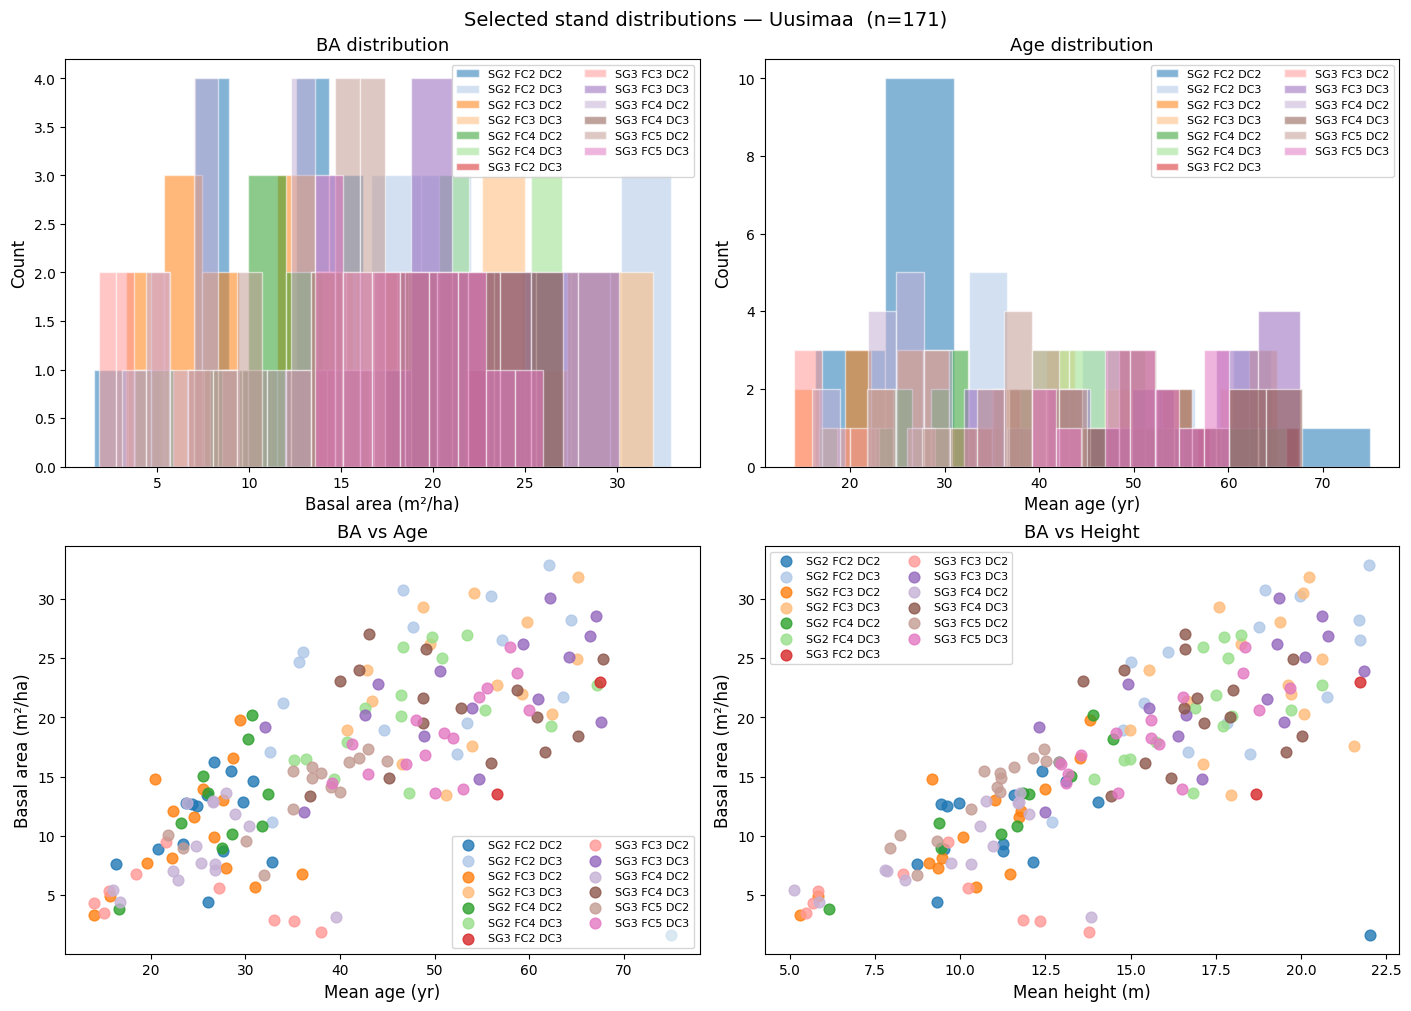

In [20]:
"""
Distribution plots: BA and age across the selected stands,
grouped by stratum (subgroup × fertilityclass × developmentclass).
"""
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
fig.suptitle(f"Selected stand distributions — {REGION_TAG}  (n={len(selected)})", fontsize=14)

# Helper: scatter with stratum colour
def stratum_label(r):
    return f"SG{int(r['subgroup'])} FC{int(r['fertilityclass'])} DC{int(r['developmentclass'])}"

selected["stratum_label"] = selected.apply(stratum_label, axis=1)
colours = plt.cm.tab20.colors
strat_labels = sorted(selected["stratum_label"].unique())
c_map = {s: colours[i % len(colours)] for i, s in enumerate(strat_labels)}

# ① BA histogram
ax = axes[0, 0]
for sl in strat_labels:
    sub = selected[selected["stratum_label"] == sl]["stand_basalarea"].dropna()
    ax.hist(sub, bins=8, alpha=0.55, color=c_map[sl], label=sl, edgecolor="white")
ax.set_xlabel("Basal area (m²/ha)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("BA distribution", fontsize=13)
ax.legend(fontsize=8, ncol=2)

# ② Age histogram
ax = axes[0, 1]
for sl in strat_labels:
    sub = selected[selected["stratum_label"] == sl]["stand_meanage"].dropna()
    ax.hist(sub, bins=8, alpha=0.55, color=c_map[sl], label=sl, edgecolor="white")
ax.set_xlabel("Mean age (yr)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Age distribution", fontsize=13)
ax.legend(fontsize=8, ncol=2)

# ③ BA vs Age scatter
ax = axes[1, 0]
for sl in strat_labels:
    sub = selected[selected["stratum_label"] == sl]
    ax.scatter(sub["stand_meanage"], sub["stand_basalarea"],
               color=c_map[sl], label=sl, s=60, alpha=0.8)
ax.set_xlabel("Mean age (yr)", fontsize=12)
ax.set_ylabel("Basal area (m²/ha)", fontsize=12)
ax.set_title("BA vs Age", fontsize=13)
ax.legend(fontsize=8, ncol=2)

# ④ BA vs Mean height scatter
ax = axes[1, 1]
for sl in strat_labels:
    sub = selected[selected["stratum_label"] == sl]
    ax.scatter(sub["stand_meanheight"], sub["stand_basalarea"],
               color=c_map[sl], label=sl, s=60, alpha=0.8)
ax.set_xlabel("Mean height (m)", fontsize=12)
ax.set_ylabel("Basal area (m²/ha)", fontsize=12)
ax.set_title("BA vs Height", fontsize=13)
ax.legend(fontsize=8, ncol=2)

plt.show()


In [17]:
"""
Distribution plots: BA and age across the selected stands,
grouped by stratum (subgroup × fertilityclass × developmentclass).
"""
import matplotlib.ticker as mtick

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
fig.suptitle(f"Selected stand distributions — {REGION_TAG}  (n={len(selected)})", fontsize=14)

# Helper: scatter with stratum colour
def stratum_label(r):
    return f"SG{int(r['subgroup'])} FC{int(r['fertilityclass'])} DC{int(r['developmentclass'])}"

selected["stratum_label"] = selected.apply(stratum_label, axis=1)
colours = plt.cm.tab20.colors
strat_labels = sorted(selected["stratum_label"].unique())
c_map = {s: colours[i % len(colours)] for i, s in enumerate(strat_labels)}

# ① BA histogram
ax = axes[0, 0]
for sl in strat_labels:
    sub = selected[selected["stratum_label"] == sl]["stand_basalarea"].dropna()
    ax.hist(sub, bins=8, alpha=0.55, color=c_map[sl], label=sl, edgecolor="white")
ax.set_xlabel("Basal area (m²/ha)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("BA distribution", fontsize=13)
ax.legend(fontsize=8, ncol=2)

# ② Age histogram
ax = axes[0, 1]
for sl in strat_labels:
    sub = selected[selected["stratum_label"] == sl]["stand_meanage"].dropna()
    ax.hist(sub, bins=8, alpha=0.55, color=c_map[sl], label=sl, edgecolor="white")
ax.set_xlabel("Mean age (yr)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Age distribution", fontsize=13)
ax.legend(fontsize=8, ncol=2)

# ③ BA vs Age scatter
ax = axes[1, 0]
for sl in strat_labels:
    sub = selected[selected["stratum_label"] == sl]
    ax.scatter(sub["stand_meanage"], sub["stand_basalarea"],
               color=c_map[sl], label=sl, s=60, alpha=0.8)
ax.set_xlabel("Mean age (yr)", fontsize=12)
ax.set_ylabel("Basal area (m²/ha)", fontsize=12)
ax.set_title("BA vs Age", fontsize=13)
ax.legend(fontsize=8, ncol=2)

# ④ BA vs Mean height scatter
ax = axes[1, 1]
for sl in strat_labels:
    sub = selected[selected["stratum_label"] == sl]
    ax.scatter(sub["stand_meanheight"], sub["stand_basalarea"],
               color=c_map[sl], label=sl, s=60, alpha=0.8)
ax.set_xlabel("Mean height (m)", fontsize=12)
ax.set_ylabel("Basal area (m²/ha)", fontsize=12)
ax.set_title("BA vs Height", fontsize=13)
ax.legend(fontsize=8, ncol=2)

plt.show()


NameError: name 'plt' is not defined

In [ ]:
"""
 Print a SUSI-ready file manifest.

Shows the AllometryParams dominant/subdominant entries (using the new
"filename.xlsx::sheet_name" syntax) for each selected stand, ready to
paste into a simulation script.

The "::" syntax is handled by the updated AllometryParams.parse_excels in
susi_parameter_model.py — backward-compatible with old single-stand files.
"""

print("=" * 80)
print(f"SUSI AllometryParams entries — {REGION_TAG}")
print("=" * 80)

for stratum_id, grp in gs_df.groupby("stratum_id"):
    print(f"\n# Stratum: {stratum_id}  ({len(grp)} stands)")
    for _, r in grp.iterrows():
        fname = r["file"]
        dom   = f"{fname}::dom_{r['standid']}"
        sub   = f"{fname}::sub_{r['standid']}"
        print(f"  stand {r['standid']:>8s}  age≈{r['initial_age']:>3}  BA≈{r['BA']:4.1f}  "
              f"dom_sp={r['dom_sp']}  sub_sp={r['sub_sp']}")
        print(f"    dominant   = {{1: \"{dom}\"}}")
        print(f"    subdominant = {{0: \"{dom}\", 1: \"{sub}\"}}")

print()
print("=" * 80)
print("SPECIES_FILES dict (for use in simulation scripts like")
print("water_management_young_stands_test.py):")
print()
print("SPECIES_FILES = {")
for sp_name, sp_code in [("Pine", 1), ("Spruce", 2)]:
    dom_entries = [
        f'"{r[\"file\"]}::dom_{r[\"standid\"]}"'
        for _, r in gs_df.iterrows()
        if int(r["dom_sp"]) == sp_code
    ]
    print(f'    "{sp_name}": [')
    for e in dom_entries:
        print(f"        {e},")
    print("    ],")
print("}")


112.71428571428571